<a href="https://colab.research.google.com/github/vitoriaferreirap/DeepLearning/blob/main/MachineLearning/SistemasInteligentes/SistemasInteligentes_ClassificadorCavalos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# dataset de cavalos kaggle
import kagglehub
# executa função do dataset e python baixa arquivos e salva cominho da pasta
path = kagglehub.dataset_download("olgabelitskaya/horse-breeds")
# caminho onde os arquivos foram salvos
print("Pasta que as imagens estão guardadas:", path)

In [ ]:
# dataset de pessoas kaggle
# usando pandas para selecionar alearotiamente uma quantidade de imagens do dataset
import kagglehub

path = kagglehub.dataset_download("ahmadahmadzada/images2000")
print("Pasta que as imagens estão guardadas:", path)


In [ ]:
import os
import shutil
import random
from google.colab import drive

drive.mount('/content/drive')

# Definição de caminhos
diretorio_dataset_cavalos = "/root/.cache/kagglehub/datasets/olgabelitskaya/horse-breeds/versions/27"
diretorio_dataset_nao_cavalos = "/root/.cache/kagglehub/datasets/ahmadahmadzada/images2000/versions/1"
diretorio_destinoDrive = "/content/drive/MyDrive/Trabalho_SistemasInteligentes"

# Pasta temporária para organizar antes de zipar
pasta_temp = "/content/temp_dataset"
os.makedirs(pasta_temp, exist_ok=True)

# Função para selecionar e preparar dados
def preparar_dados():
    caminhos_cavalos = [os.path.join(raiz, arq) for raiz, _, arqs in os.walk(diretorio_dataset_cavalos) for arq in arqs if arq.lower().endswith(('.png', '.jpg', '.jpeg'))]
    caminhos_nao_cavalos_full = [os.path.join(raiz, arq) for raiz, _, arqs in os.walk(diretorio_dataset_nao_cavalos) for arq in arqs if arq.lower().endswith(('.png', '.jpg', '.jpeg'))]

    qtd_ideal = min(len(cavalos_sel := caminhos_cavalos[:len(caminhos_cavalos)]), len(caminhos_nao_cavalos_full))
    caminhos_nao_cavalos_sel = random.sample(caminhos_nao_cavalos_full, qtd_ideal)

    return caminhos_cavalos[:qtd_ideal], caminhos_nao_cavalos_sel

cavalos, nao_cavalos = preparar_dados()

# Organizar em pastas temporárias e renomear
def organizar(lista, pasta_nome):
    destino = os.path.join(pasta_temp, pasta_nome)
    os.makedirs(destino, exist_ok=True)
    for i, origem in enumerate(lista, 1):
        ext = os.path.splitext(origem)[1]
        shutil.copy2(origem, os.path.join(destino, f"{i}{ext}"))
    return destino

dir_cav = organizar(cavalos, "cavalos")
dir_nao = organizar(nao_cavalos, "nao_cavalos")

# Compactar e mover para o Drive
print("Compactando e enviando para o Drive...")
shutil.make_archive(os.path.join(diretorio_destinoDrive, "cavalos"), 'zip', dir_cav)
shutil.make_archive(os.path.join(diretorio_destinoDrive, "nao_cavalos"), 'zip', dir_nao)

# Limpeza
shutil.rmtree(pasta_temp)

print("Processo finalizado com sucesso. Arquivos .zip criados no seu Drive.")

# Inicio de execução ao ter o dataset no drive:

In [1]:
import zipfile
import os
import shutil
from google.colab import drive

# Montar Drive
drive.mount('/content/drive', force_remount=True)

# Configurações
caminho_drive = '/content/drive/MyDrive/Beckup_IC/Trabalho_SistemasInteligentes'
caminho_local = '/content/'

# Dicionário mapeando o nome do arquivo ZIP para a pasta de destino desejada
processos = {
    'cavalos.zip': 'cavalos',
    'nao_cavalos.zip': 'nao_cavalos'
}

# Execução
for nome_zip, pasta_destino in processos.items():
    caminho_origem_zip = os.path.join(caminho_drive, nome_zip)
    caminho_pasta_final = os.path.join(caminho_local, pasta_destino)

    # Cria a pasta de destino (garante que exista)
    os.makedirs(caminho_pasta_final, exist_ok=True)

    if os.path.exists(caminho_origem_zip):
        print(f"Extraindo {nome_zip} para {caminho_pasta_final}...")

        # Extrai o conteúdo direto para a pasta correta
        with zipfile.ZipFile(caminho_origem_zip, 'r') as zip_ref:
            zip_ref.extractall(caminho_pasta_final)

        print(f"Sucesso: {nome_zip} extraído.")
    else:
        print(f"Erro: Arquivo {nome_zip} não encontrado em {caminho_drive}")

#  Verificação final
print("\nEstrutura atual em /content/:")
for item in os.listdir(caminho_local):
    caminho_item = os.path.join(caminho_local, item)
    if os.path.isdir(caminho_item) and item in ['cavalos', 'nao_cavalos']:
        qtd = len(os.listdir(caminho_item))
        print(f"Pasta '{item}' contém {qtd} arquivos.")

Mounted at /content/drive
Extraindo cavalos.zip para /content/cavalos...
Sucesso: cavalos.zip extraído.
Extraindo nao_cavalos.zip para /content/nao_cavalos...
Sucesso: nao_cavalos.zip extraído.

Estrutura atual em /content/:
Pasta 'nao_cavalos' contém 670 arquivos.
Pasta 'cavalos' contém 670 arquivos.


# Para classificar se é cavalo ou não:
- A classificação binária SEMPRE exigirá o 'conhecimento' do que é e do que não é o seu objetivo.
- Como um classificador de tarefa de aprendizado supervisionado, o modelo, obrigatoriamente, deve diferenciar o que é a classe A e o que NÃO é a classe A.
- Todos os filtros de extração de características devem ser aplicados em ambas as classes, para que o modelo tenha exemplos positivos e negativos das características extraídas (bordas, texturas, silhueta) que caracterizam um cavalo e o que o diferencia de um ser humano ou paisagem.

# Pré-processamento e Extração de Característica 1
### 1) Padronização e Intensidade Luminosa (Tons de Cinza)
Imagens brutas não podem ser entregues diretamente aos classificadores, pois os algoritmos precisam que elas sejam transformadas em matrizes numéricas padronizadas para conseguirem calcular a distância geométrica entre os pixels.

* **O Pré-processamento Técnico:** Consiste em redimensionar a imagem para $64 \times 64$ pixels, mudar o tipo de dado (geralmente para `float32`) e, no final de tudo, achatar a matriz (aplicar o `flatten`) para transformá-la em um vetor linear. Isso garante que todas as entradas do dataset tenham exatamente o mesmo tamanho e formato exigidos pelo classificador.

* **Característica 1 (Tons de Cinza):** A conversão da imagem colorida para tons de cinza cumpre um papel duplo. Ela funciona como pré-processamento (porque a maioria dos filtros matemáticos das próximas etapas exige uma imagem de canal único para funcionar), mas também é a primeira extração de característica. Ela extrai o **Mapa de Intensidade Luminosa**, entregando ao classificador os valores puros de brilho e iluminação do corpo do animal e do cenário.

**Fluxo Prático:** Todos os filtros seguintes (Sobel, Laplaciano, Gaussiano, Mediana e Canny) são aplicados em cima desta imagem já convertida para cinza e redimensionada para $64 \times 64$. Isso garante que todas as 7 matrizes de características nasçam com o mesmo tamanho físico antes de serem achatadas para um algoritmo de classificação.

FLUXO DE EXECUÇÃO - Classe CAVALO: Raio x do pré-processamento


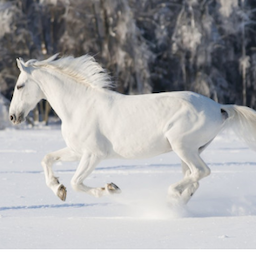

-------------------------------------------------------
Formato original da imagem (Estrutura física): (256, 256, 3)
Tipo de dado original da imagem na memória: uint8
-------------------------------------------------------
Formato final (Estrutura física): (670, 4096)
Tipo do dado final na memória: float32
Visualização - Característica 1 - CAVALO, CONVERSÃO DE TONS E REDIMENSIONAMENTO:


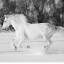

-------------------------------------------------------
EX COMO UMA IMAGEM VIRA VETOR, FOCANDO APENAS NA CARACTÉRISTICA 1 CAVALO:
Visualização dos 10 primeiros pixels no vetor:
 [139. 108.  91.  85.  91.  83.  56.  47.  76.  82.]
-------------------------------------------------------
--- TESTE DE DIAGNÓSTICO: Iniciando processamento da classe NÃO CAVALO ---
FLUXO DE EXECUÇÃO - Classe NÃO CAVALO: Raio x do pré-processamento


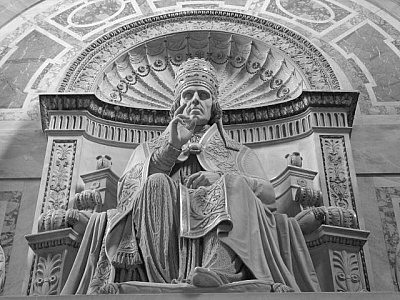

-------------------------------------------------------
MÉTRICAS INICIAIS DA IMAGEM DE ENTRADA
Formato original da imagem (Estrutura física): (300, 400, 3)
Tipo de dado original da imagem na memória: uint8
-------------------------------------------------------
Formato final (Estrutura física): (670, 4096)
Tipo do dado final na memória: float32
Visualização - Característica 1 - NÃO CAVALO, CONVERSÃO DE TONS E REDIMENSIONAMENTO:


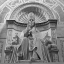

-------------------------------------------------------
COMO UMA IMAGEM VIRA VETOR, FOCANDO APENAS NA CARACTÉRISTICA 1 NÃO CAVALO :
Visualização dos 10 primeiros pixels no vetor:
 [193. 193. 190. 187. 184. 173. 174. 225. 232. 219.]
-------------------------------------------------------


In [2]:
import numpy as np
import cv2 as cv
import os
from google.colab.patches import cv2_imshow

# MANTER ESTAS VARIÁVEIS ATUALIZADAS PARA O LOCAL:
diretorio_destinoDrive_cavalos = "/content/cavalos"
diretorio_destinoDrive_nao_cavalos = "/content/nao_cavalos"

# Listar arquivos que estão dentro da pasta
arquivos_cavalos = os.listdir(diretorio_destinoDrive_cavalos)
arquivos_nao_cavalos = os.listdir(diretorio_destinoDrive_nao_cavalos)

# Listas para armazenar os resultados
resultadoVetores_cavalos = []
resultadoVetores_nao_cavalos = []

# Lista para guardar todas as imagems apos o pré-processamento, extração de caracteristica 1
imagensCom_Caracteristica1_cavalos = []
imagensCom_Caracteristica1_nao_cavalos = []

# EXTRAÇÃO CARACTERISTICAS DATASET CAVALOS
for nome_arquivo in arquivos_cavalos:
    # Cria o caminho completo para cada imagem (ex: /.../datasetCavalos/1.jpg)
    caminhoCompleto = os.path.join(diretorio_destinoDrive_cavalos, nome_arquivo)
    # Carrega a imagem atual
    img_original_cavalo = cv.imread(caminhoCompleto)

    # --- LOG DE SEGURANÇA ---
    if img_original_cavalo is None:
        print(f"AVISO: Pulando arquivo corrompido em CAVALOS: {nome_arquivo}")
        continue

    # converter imgs para tons de cinza
    caracteristica_1_cavalo = cv.cvtColor(img_original_cavalo, cv.COLOR_BGR2GRAY)

    # REPRESENTAÇÃO DA MESMA IMAGEM - PRIMEIRA: IMGREDIMENCIONADA - 64,64
    # REPRESENTACAO DA MESMA IMAGEM  - SEGUNDA: VETORCARACTERISTICAS - 4096 MESMA INFO MAS ACHATADA

    # redimensionar imgs
    tamanhoPadrao = (64, 64)
    imgRedimensionada_cavalos = cv.resize(caracteristica_1_cavalo, tamanhoPadrao, interpolation=cv.INTER_AREA)

    # Apenas para ver o logs:
    # Passo A: Achatar a matriz transformando em vetor unidimensional
    imagemAchatada_cavalo = imgRedimensionada_cavalos.flatten()
    # Passo B: Mudar o tipo do dado na memória para o padrão do k-NN
    vetorCaracteristicas = imagemAchatada_cavalo.astype(np.float32)
    resultadoVetores_cavalos.append(vetorCaracteristicas)

    # armazenando todas as imagens com caracteristica 1 já extraida
    imagensCom_Caracteristica1_cavalos.append(imgRedimensionada_cavalos)

# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_cavalos_np = np.array(resultadoVetores_cavalos)

print("FLUXO DE EXECUÇÃO - Classe CAVALO: Raio x do pré-processamento")
cv2_imshow(img_original_cavalo)
print("-" * 55)

print("Formato original da imagem (Estrutura física):", img_original_cavalo.shape)
print("Tipo de dado original da imagem na memória:", img_original_cavalo.dtype)
print("-" * 55)

print("Formato final (Estrutura física):", resultadoVetores_cavalos_np.shape)
print("Tipo do dado final na memória:", resultadoVetores_cavalos_np.dtype)

print("Visualização - Característica 1 - CAVALO, CONVERSÃO DE TONS E REDIMENSIONAMENTO:")
cv2_imshow(imgRedimensionada_cavalos)
print("-" * 55)

print("EX COMO UMA IMAGEM VIRA VETOR, FOCANDO APENAS NA CARACTÉRISTICA 1 CAVALO:")
print("Visualização dos 10 primeiros pixels no vetor:")
print("", vetorCaracteristicas[:10])
print("-" * 55)

#EXTRAÇÃO CARACTERISTICAS DATASET NÃO CAVALOS
print("--- TESTE DE DIAGNÓSTICO: Iniciando processamento da classe NÃO CAVALO ---")
voltas = 0
for nome_arquivo in arquivos_nao_cavalos:
    voltas += 1

    # Cria o caminho completo para cada imagem
    caminhoCompleto = os.path.join(diretorio_destinoDrive_nao_cavalos, nome_arquivo)

    # Carrega a imagem atual
    img_original_nao_cavalos = cv.imread(caminhoCompleto)

    # --- LOG DE SEGURANÇA ---
    if img_original_nao_cavalos is None:
        print(f"AVISO: Pulando arquivo corrompido em NÃO CAVALOS (volta {voltas}): {nome_arquivo}")
        continue

    # converter imgs para tons de cinza
    caracteristica_1_nao_cavalos = cv.cvtColor(img_original_nao_cavalos, cv.COLOR_BGR2GRAY)
    # redimensionar imgs
    tamanhoPadrao = (64, 64)
    imgRedimensionada_nao_cavalos = cv.resize(caracteristica_1_nao_cavalos, tamanhoPadrao, interpolation=cv.INTER_AREA)

    # Passo A: Achatar a matriz transformando em vetor unidimensional
    imagemAchatada_nao_cavalos = imgRedimensionada_nao_cavalos.flatten()
    # Passo B: Mudar o tipo do dado na memória para o padrão do k-NN
    vetorCaracteristicas = imagemAchatada_nao_cavalos.astype(np.float32)

    resultadoVetores_nao_cavalos.append(vetorCaracteristicas)
    imagensCom_Caracteristica1_nao_cavalos.append(imgRedimensionada_nao_cavalos)

# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_nao_cavalos_np = np.array(resultadoVetores_nao_cavalos)

print("FLUXO DE EXECUÇÃO - Classe NÃO CAVALO: Raio x do pré-processamento")
cv2_imshow(img_original_nao_cavalos)
print("-" * 55)

print("MÉTRICAS INICIAIS DA IMAGEM DE ENTRADA")
print("Formato original da imagem (Estrutura física):", img_original_nao_cavalos.shape)
print("Tipo de dado original da imagem na memória:", img_original_nao_cavalos.dtype)
print("-" * 55)

print("Formato final (Estrutura física):", resultadoVetores_nao_cavalos_np.shape)
print("Tipo do dado final na memória:", resultadoVetores_nao_cavalos_np.dtype)
print("Visualização - Característica 1 - NÃO CAVALO, CONVERSÃO DE TONS E REDIMENSIONAMENTO:")
cv2_imshow(imgRedimensionada_nao_cavalos)
print("-" * 55)

print("COMO UMA IMAGEM VIRA VETOR, FOCANDO APENAS NA CARACTÉRISTICA 1 NÃO CAVALO :")
print("Visualização dos 10 primeiros pixels no vetor:")
print("", vetorCaracteristicas[:10])
print("-" * 55)

# Extração de Características:
### 2) Bordas e Gradientes

Esta célula executa a extração de características através da aplicação de filtros matemáticos independentes sobre a matriz de $64 \times 64$ em tons de cinza. A partir de uma única imagem de entrada, o fluxo gera **3 matrizes de características totalmente distintas** para os algoritmos de classificação:

1. **Sobel X:** Destaca as **bordas verticais** (percorre o eixo X e captura linhas verticais, como as pernas do animal).
2. **Sobel Y:** Destaca as **bordas horizontais** (percorre o eixo Y e captura linhas horizontais, como o dorso).
3. **Laplaciano:** Mapeia o **relevo geral**, capturando todas as direções de contorno simultaneamente.

**Nota Matemática de Implementação:** As transições de cor geram valores positivos e negativos na memória. Por isso, o código utiliza a profundidade `cv.CV_64F` para preservar os gradientes negativos, aplica o valor absoluto com `np.absolute()` e converte o tipo final para `float32`, formato padrão exigido para o cálculo de distância dos classificadores.

* **Hiperparâmetros configuráveis de teste:** Tamanho do Kernel (`ksize`), Direção da Derivada (`xorder`/`yorder`) e a variação estável do Filtro de Scharr.

Visualização - Característica 2 - CAVALO: Sobel X (Bordas Verticais)


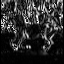

-------------------------------------------------------
Visualização - Característica 3 - CAVALO: Sobel Y (Bordas Horizontais)


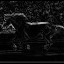

-------------------------------------------------------
Visualização - Característica 4 - CAVALO: Laplacian X (Todas as bordas)


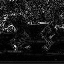

-------------------------------------------------------
Visualização - Característica 2 - NÃO CAVALO: Sobel X (Bordas Verticais)


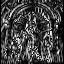

-------------------------------------------------------
Visualização - Característica 3 - NÃO CAVALO: Sobel Y (Bordas Horizontais)


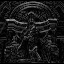

-------------------------------------------------------
Visualização - Característica 4 - NÃO CAVALO: Laplacian X (Todas as bordas)


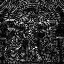

-------------------------------------------------------


In [3]:
# EXTRAÇÃO CARACTERISTICAS DATASET CAVALOS
resultadoVetores_caracteristica2_cavalos = []
resultadoVetores_caracteristica3_cavalos = []
resultadoVetores_caracteristica4_cavalos = []

for imgRedimensionada_cavalos in imagensCom_Caracteristica1_cavalos:
    # Função SOBEL x Gradiente Horizontal (mátematicamente calcula a derivada parcial horizontal)
    sobel_x_float = cv.Sobel(imgRedimensionada_cavalos, cv.CV_64F, 1, 0, ksize=3)
    # tranforma negativos em positivos
    sobel_x_absoluto_cavalo = np.absolute(sobel_x_float)
    # tipo para o uso do knn
    caracteristica_2_cavalo = sobel_x_absoluto_cavalo.astype(np.float32)
    resultadoVetores_caracteristica2_cavalos.append(caracteristica_2_cavalo.flatten())

    # Função SOBEL x Gradiente Vertical (mátematicamente calcula a derivada parcial vertical)
    sobel_y_float_cavalo = cv.Sobel(imgRedimensionada_cavalos, cv.CV_64F, 0, 1, ksize=1)
    sobel_y_absoluto_cavalo = np.absolute(sobel_y_float_cavalo)
    caracteristica_3_cavalo = sobel_y_absoluto_cavalo.astype(np.float32)
    resultadoVetores_caracteristica3_cavalos.append(caracteristica_3_cavalo.flatten())

    # Função LAPLACIANO x Gradiente de Segunda Ordem (calcula a soma das segundas derivadas especiais)
    laplacian_float_cavalo = cv.Laplacian(imgRedimensionada_cavalos, cv.CV_64F)
    # tranforma negativos em positivos
    laplacian_absoluto_cavalo = np.absolute(laplacian_float_cavalo)
    # tipo para o uso do knn
    caracteristica_4_cavalo = laplacian_absoluto_cavalo.astype(np.float32)
    resultadoVetores_caracteristica4_cavalos.append(caracteristica_4_cavalo.flatten())

# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_caracteristica2_cavalos_np = np.array(resultadoVetores_caracteristica2_cavalos)
resultadoVetores_caracteristica3_cavalos_np = np.array(resultadoVetores_caracteristica3_cavalos)
resultadoVetores_caracteristica4_cavalos_np = np.array(resultadoVetores_caracteristica4_cavalos)

# Conversão necessária apenas para a TELA conseguir MOSTRAR IMAGENS NOS LOGS
imagem_visual_x_cavalo = np.uint8(sobel_x_absoluto_cavalo)
imagem_visual_y_cavalo = np.uint8(sobel_y_absoluto_cavalo)
imagem_visual_lap_cavalo = np.uint8(laplacian_absoluto_cavalo)

print("Visualização - Característica 2 - CAVALO: Sobel X (Bordas Verticais)")
cv2_imshow(imagem_visual_x_cavalo)
print("-" * 55)
print("Visualização - Característica 3 - CAVALO: Sobel Y (Bordas Horizontais)")
cv2_imshow(imagem_visual_y_cavalo)
print("-" * 55)
print("Visualização - Característica 4 - CAVALO: Laplacian X (Todas as bordas)")
cv2_imshow(imagem_visual_lap_cavalo)
print("-" * 55)

# EXTRAÇÃO CARACTERISTICAS DATASET NÃO CAVALOS
resultadoVetores_caracteristica2_nao_cavalos = []
resultadoVetores_caracteristica3_nao_cavalos = []
resultadoVetores_caracteristica4_nao_cavalos = []

for imgRedimensionada_nao_cavalos in imagensCom_Caracteristica1_nao_cavalos:
    # Função SOBEL x Gradiente Horizontal (mátematicamente calcula a derivada parcial horizontal)
    sobel_x_float_nao_cavalos = cv.Sobel(imgRedimensionada_nao_cavalos, cv.CV_64F, 1, 0, ksize=3)
    # tranforma negativos em positivos
    sobel_x_absoluto_nao_cavalos = np.absolute(sobel_x_float_nao_cavalos)
    # tipo para o uso do knn
    caracteristica_2_nao_cavalos = sobel_x_absoluto_nao_cavalos.astype(np.float32)
    # conversao numPy
    resultadoVetores_caracteristica2_nao_cavalos.append(caracteristica_2_nao_cavalos.flatten())

    # Função SOBEL x Gradiente Vertical (mátematicamente calcula a derivada parcial vertical)
    sobel_y_float_nao_cavalos = cv.Sobel(imgRedimensionada_nao_cavalos, cv.CV_64F, 0, 1, ksize=1)
    sobel_y_absoluto_nao_cavalos = np.absolute(sobel_y_float_nao_cavalos)
    caracteristica_3_nao_cavalos = sobel_y_absoluto_nao_cavalos.astype(np.float32)
    resultadoVetores_caracteristica3_nao_cavalos.append(caracteristica_3_nao_cavalos.flatten())

    # Função LAPLACIANO x Gradiente de Segunda Ordem (calcula a soma das segundas derivadas especiais)
    laplacian_float_nao_cavalos = cv.Laplacian(imgRedimensionada_nao_cavalos, cv.CV_64F)
    # tranforma negativos em positivos
    laplacian_absoluto_nao_cavalos = np.absolute(laplacian_float_nao_cavalos)
    # tipo para o uso do knn
    caracteristica_4_nao_cavalos = laplacian_absoluto_nao_cavalos.astype(np.float32)
    resultadoVetores_caracteristica4_nao_cavalos.append(caracteristica_4_nao_cavalos.flatten())

# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_caracteristica2_nao_cavalos_np = np.array(resultadoVetores_caracteristica2_nao_cavalos)
resultadoVetores_caracteristica3_nao_cavalos_np = np.array(resultadoVetores_caracteristica3_nao_cavalos)
resultadoVetores_caracteristica4_nao_cavalos_np = np.array(resultadoVetores_caracteristica4_nao_cavalos)

# Conversão necessária apenas para a TELA conseguir MOSTRAR IMAGENS NOS LOGS
imagem_visual_x_nao_cavalos = np.uint8(sobel_x_absoluto_nao_cavalos)
imagem_visual_y_nao_cavalos = np.uint8(sobel_y_absoluto_nao_cavalos)
imagem_visual_lap_nao_cavalos = np.uint8(laplacian_absoluto_nao_cavalos)

print("Visualização - Característica 2 - NÃO CAVALO: Sobel X (Bordas Verticais)")
cv2_imshow(imagem_visual_x_nao_cavalos)
print("-" * 55)
print("Visualização - Característica 3 - NÃO CAVALO: Sobel Y (Bordas Horizontais)")
cv2_imshow(imagem_visual_y_nao_cavalos)
print("-" * 55)
print("Visualização - Característica 4 - NÃO CAVALO: Laplacian X (Todas as bordas)")
cv2_imshow(imagem_visual_lap_nao_cavalos)
print("-" * 55)

Visualização - Característica 5 - CAVALO: Desfoque Gaussiano (Suavização Natural)


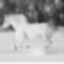

-------------------------------------------------------
Visualização - Característica 6 - CAVALO: Filtro de Mediana (Redução de Ruído com Bordas Firmes)


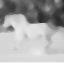

-------------------------------------------------------
Visualização - Característica 7 - CAVALO: Filtro Canny ( Detecção de Bordas de Canny)


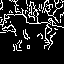

-------------------------------------------------------
Visualização - Característica 5 - NÃO CAVALO: Desfoque Gaussiano (Suavização Natural)


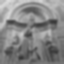

-------------------------------------------------------
Visualização - Característica 6 - NÃO CAVALO: Filtro de Mediana (Redução de Ruído com Bordas Firmes)


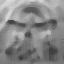

-------------------------------------------------------
Visualização - Característica 7 - NÃO CAVALO: Filtro Canny ( Detecção de Bordas de Canny)


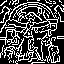

-------------------------------------------------------


In [4]:
#EXTRAÇÃO CARACTERISTICAS DATASET CAVALOS

# Listas para armazenar os resultados
resultadoVetores_caracteristica5_cavalos = []
resultadoVetores_caracteristica6_cavalos = []
resultadoVetores_caracteristica7_cavalos = []

for imgRedimensionada_cavalos in imagensCom_Caracteristica1_cavalos:

    # Desfoque Gaussiano
    gaussian_float_cavalo = cv.GaussianBlur(imgRedimensionada_cavalos, (5, 5), 0)
    # tranforma negativos em positivos
    caracteristica_5_cavalo = gaussian_float_cavalo.astype(np.float32)
    # transformar imagem em vetor para o k-NN
    vetorCaracteristica5 = caracteristica_5_cavalo.flatten()
    resultadoVetores_caracteristica5_cavalos.append(vetorCaracteristica5)

    # Filtro de Mediana
    median_float_cavalo = cv.medianBlur(imgRedimensionada_cavalos, 5)
    caracteristica_6_cavalo = median_float_cavalo.astype(np.float32)
    vetorCaracteristica6 = caracteristica_6_cavalo.flatten()
    resultadoVetores_caracteristica6_cavalos.append(vetorCaracteristica6)

    # Canny
    canny_float_cavalo = cv.Canny(imgRedimensionada_cavalos, 100, 200)
    caracteristica_7_cavalo = canny_float_cavalo.astype(np.float32)
    vetorCaracteristica7 = caracteristica_7_cavalo.flatten()
    resultadoVetores_caracteristica7_cavalos.append(vetorCaracteristica7)


# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_caracteristica5_cavalos_np = np.array(resultadoVetores_caracteristica5_cavalos)
resultadoVetores_caracteristica6_cavalos_np = np.array(resultadoVetores_caracteristica6_cavalos)
resultadoVetores_caracteristica7_cavalos_np = np.array(resultadoVetores_caracteristica7_cavalos)

print("Visualização - Característica 5 - CAVALO: Desfoque Gaussiano (Suavização Natural)")
imagem_visual_gauss_cavalo = np.uint8(caracteristica_5_cavalo)
cv2_imshow(imagem_visual_gauss_cavalo)
print("-" * 55)

print("Visualização - Característica 6 - CAVALO: Filtro de Mediana (Redução de Ruído com Bordas Firmes)")
imagem_visual_median_cavalo = np.uint8(caracteristica_6_cavalo)
cv2_imshow(imagem_visual_median_cavalo)
print("-" * 55)

print("Visualização - Característica 7 - CAVALO: Filtro Canny ( Detecção de Bordas de Canny)")
imagem_visual_canny_cavalo = np.uint8(caracteristica_7_cavalo)
cv2_imshow(imagem_visual_canny_cavalo)
print("-" * 55)


#EXTRAÇÃO CARACTERISTICAS DATASET NÃO CAVALOS
# Listas para armazenar os resultados
resultadoVetores_caracteristica5_nao_cavalos = []
resultadoVetores_caracteristica6_nao_cavalos = []
resultadoVetores_caracteristica7_nao_cavalos = []

for imgRedimensionada_nao_cavalos in imagensCom_Caracteristica1_nao_cavalos:

    # Desfoque  Gaussiano
    gaussian_float_nao_cavalos = cv.GaussianBlur(imgRedimensionada_nao_cavalos, (5, 5), 0)
    caracteristica_5_nao_cavalos = gaussian_float_nao_cavalos.astype(np.float32)
    vetorCaracteristica5 = caracteristica_5_nao_cavalos.flatten()
    resultadoVetores_caracteristica5_nao_cavalos.append(vetorCaracteristica5)

    # Mediana gaussian_float
    median_float_nao_cavalos = cv.medianBlur(imgRedimensionada_nao_cavalos, 5)
    caracteristica_6_nao_cavalos = median_float_nao_cavalos.astype(np.float32)
    vetorCaracteristica6 = caracteristica_6_nao_cavalos.flatten()
    resultadoVetores_caracteristica6_nao_cavalos.append(vetorCaracteristica6)

    # Canny
    canny_float_nao_cavalos = cv.Canny(imgRedimensionada_nao_cavalos, 100, 200)
    caracteristica_7_nao_cavalos = canny_float_nao_cavalos.astype(np.float32)
    vetorCaracteristica7 = caracteristica_7_nao_cavalos.flatten()
    resultadoVetores_caracteristica7_nao_cavalos.append(vetorCaracteristica7)

# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_caracteristica5_nao_cavalos_np = np.array(resultadoVetores_caracteristica5_nao_cavalos)
resultadoVetores_caracteristica6_nao_cavalos_np = np.array(resultadoVetores_caracteristica6_nao_cavalos)
resultadoVetores_caracteristica7_nao_cavalos_np = np.array(resultadoVetores_caracteristica7_nao_cavalos)

print("Visualização - Característica 5 - NÃO CAVALO: Desfoque Gaussiano (Suavização Natural)")
imagem_visual_gauss_nao_cavalos = np.uint8(caracteristica_5_nao_cavalos)
cv2_imshow(imagem_visual_gauss_nao_cavalos)
print("-" * 55)

print("Visualização - Característica 6 - NÃO CAVALO: Filtro de Mediana (Redução de Ruído com Bordas Firmes)")
imagem_visual_median_nao_cavalos = np.uint8(caracteristica_6_nao_cavalos)
cv2_imshow(imagem_visual_median_nao_cavalos)
print("-" * 55)

print("Visualização - Característica 7 - NÃO CAVALO: Filtro Canny ( Detecção de Bordas de Canny)")
imagem_visual_canny_nao_cavalos = np.uint8(caracteristica_7_nao_cavalos)
cv2_imshow(imagem_visual_canny_nao_cavalos)
print("-" * 55)

# AGRUPAMENTO (MATRIZ DE FEATURES)
## `np.concatenate()`

### É a função central para a consolidação de matrizes multidimensionais (`ndarrays`) no ecossistema NumPy. Essencial para o processamento e análise de dados, ele permite unir uma sequência de matrizes de forma rápida e eficiente em termos de memória.

**Regras de Ouro para a Concatenação:**
* **Estrutura Rígida:** Todos os elementos da tupla devem ser obrigatoriamente `Arrays NumPy` estruturados.
* **Compatibilidade de Shapes:** Os arrays precisam ter formatos compatíveis. Eles devem possuir o mesmo tamanho em todas as dimensões, exceto na dimensão em que a concatenação será realizada.
* **Dimensionalidade:** A união só pode ocorrer ao longo das dimensões existentes da matriz.

**Estrutura da Chamada:**
A função recebe dois argumentos principais: uma tupla contendo os arrays e o eixo (`axis`) de referência.

- np.concatenate((array1, array2, ...), axis=0)
    - axis=0: Empilha verticalmente (aumenta o número de linhas - ex: mais imagens)
    - axis=1: Empilha horizontalmente (aumenta o número de colunas - ex: mais atributos)

In [5]:

X_cavalos = np.concatenate(
    (resultadoVetores_cavalos_np, resultadoVetores_caracteristica2_cavalos_np,
     resultadoVetores_caracteristica3_cavalos_np, resultadoVetores_caracteristica4_cavalos_np,
     resultadoVetores_caracteristica5_cavalos_np, resultadoVetores_caracteristica6_cavalos_np,
     resultadoVetores_caracteristica7_cavalos_np), axis=1
)

X_nao_cavalos = np.concatenate(
    (resultadoVetores_nao_cavalos_np, resultadoVetores_caracteristica2_nao_cavalos_np,
     resultadoVetores_caracteristica3_nao_cavalos_np, resultadoVetores_caracteristica4_nao_cavalos_np,
     resultadoVetores_caracteristica5_nao_cavalos_np, resultadoVetores_caracteristica6_nao_cavalos_np,
     resultadoVetores_caracteristica7_nao_cavalos_np), axis=1
)

# PRINT DE CONFERÊNCIA
print("RELATÓRIO DE AGRUPAMENTO (MATRIZ DE FEATURES)")
print(f"Classe CAVALO: {X_cavalos.shape[0]} imagens | {X_cavalos.shape[1]} atributos totais")
print(f"Classe NÃO CAVALO: {X_nao_cavalos.shape[0]} imagens | {X_nao_cavalos.shape[1]} atributos totais")
print("-" * 55)

RELATÓRIO DE AGRUPAMENTO (MATRIZ DE FEATURES)
Classe CAVALO: 670 imagens | 28672 atributos totais
Classe NÃO CAVALO: 670 imagens | 28672 atributos totais
-------------------------------------------------------


## Etapa de Preparação de Dados: Pilares Universais

Independentemente do algoritmo de aprendizado escolhido, a qualidade do modelo é diretamente proporcional à integridade dos dados de entrada. A preparação segue quatro pilares fundamentais:

### 1. Limpeza e Validação (Garantia de Integridade)
Antes de qualquer processamento, asseguramos que a matriz de *features* seja confiável:
* **Tratamento de Falhas:** Identificação e remoção de amostras corrompidas ou incompletas (valores `NaN`/vazios) que comprometeriam o cálculo matemático.
* **Eliminação de Duplicatas:** Remoção de arquivos redundantes que poderiam induzir o modelo ao *overfitting* por memorização de instâncias específicas.
* **Verificação de Escrita:** Uso de checagem de integridade (tamanho de bytes) durante a transferência e carregamento dos dados para garantir que a imagem lida pelo OpenCV esteja íntegra.

### 2. Embaralhamento (*Shuffling*)
Fundamental para quebrar a ordem sequencial dos dados.
* Como datasets frequentemente vêm organizados por classe (ex: todos os cavalos, depois todos os não-cavalos), o **embaralhamento prévio** é vital. Sem ele, a divisão entre treino e teste seria tendenciosa, levando a uma falha estatística onde o modelo não seria exposto a uma distribuição realista das classes.

### 3. Divisão do Dataset (Blindagem contra *Overfitting*)
A separação correta garante que o modelo seja avaliado por sua capacidade de generalização:
* **Treino:** Conjunto de dados utilizado para o ajuste de pesos/parâmetros do modelo.
* **Teste:** Dados "virgens" que o modelo nunca viu durante o aprendizado, servindo como auditoria final de desempenho.
* **Estratificação:** Garantia de que a proporção das classes (ex: 50% cavalos, 50% não-cavalos) seja mantida tanto no treino quanto no teste, evitando viés de amostragem.

### 4. Engenharia e Transformação de *Features*
O escalonamento é o estágio crítico para algoritmos sensíveis à magnitude (como o k-NN):
* **Normalização/Padronização:** Ajuste das variáveis para uma mesma escala numérica, evitando que características com valores elevados (ex: intensidades de pixel de 0 a 255) dominem indevidamente características com escalas menores.
* **Transformação de Dimensionalidade:** Conversão de matrizes espaciais em vetores unidimensionais (achatamento), permitindo que o modelo trate a imagem como um conjunto de atributos numéricos comparáveis.

In [6]:
# Limpeza e Validação
import numpy as np
# Verificar se existem valores nulos ou infinitos nas matrizes
def validar_dados(X, nome):
   if np.isnan(X).any() or np.isinf(X).any():
       print(f"ALERTA: Dados inválidos (NaN/Inf) encontrados em {nome}")
   else:
       print(f"OK: Dados em {nome} estão limpos e prontos.")
validar_dados(X_cavalos, "X_cavalos")
validar_dados(X_nao_cavalos, "X_nao_cavalos")

OK: Dados em X_cavalos estão limpos e prontos.
OK: Dados em X_nao_cavalos estão limpos e prontos.


In [7]:
# Embaralhamento e Divisão (Estratificada)
from sklearn.model_selection import train_test_split

# Criar rótulos e concatenar (X e y já prontos)
y_cavalos = np.ones(X_cavalos.shape[0])
y_nao_cavalos = np.zeros(X_nao_cavalos.shape[0])
X = np.concatenate((X_cavalos, X_nao_cavalos), axis=0)
y = np.concatenate((y_cavalos, y_nao_cavalos), axis=0)

# Divisão: 80% treino, 20% teste
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Dados divididos: Treino={X_train.shape[0]}, Teste={X_test.shape[0]}")

Dados divididos: Treino=1072, Teste=268


### Escalonamento de Dados:
O **Escalonamento (*Scaling*)** é um termo que define o processo de ajuste dos dados para uma escala específica, garantindo que variáveis com magnitudes distintas não distorçam o aprendizado do modelo.

#### 1. Técnicas de Escalonamento
* **Normalização (Min-Max):** Redimensiona os dados para um intervalo fixo, comumente entre 0 e 1. É ideal quando a distribuição dos dados não é Gaussiana e não se deseja remover *outliers*.

* **Padronização (*Standardization*):** Ajusta os dados para possuírem média ($\mu$) igual a 0 e desvio padrão ($\sigma$) igual a 1. É uma técnica mais robusta frente a *outliers* e amplamente utilizada em algoritmos que dependem de distâncias geométricas.

#### 2. Importância e Impacto nos Modelos

* **Para o $k$-NN ($k$-Nearest Neighbors):**
    O $k$-NN baseia-se no cálculo de distâncias (ex: Euclidiana ou Manhattan). Sem a padronização, atributos com valores numéricos de maior escala dominariam matematicamente o cálculo da distância, sobrepondo-se às informações relevantes da "assinatura espacial" extraída. A padronização garante que todos os pixels e bordas contribuam de forma **equitativa** para a decisão do modelo.

* **Para o Random Forest:**
    Diferentemente do $k$-NN, o Random Forest é um algoritmo baseado em árvores que utiliza divisões (*splits*) lógicas em valores de atributos. Por natureza, ele é **invariante à escala** dos dados, visto que um corte lógico (ex: `pixel > 0.5`) permanece válido independentemente da padronização. No entanto, aplicar a padronização não compromete o desempenho, mantendo o *pipeline* de pré-processamento consistente para comparação entre múltiplos modelos (*benchmarking*).



In [8]:
# Escalonamento
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # (Padronização)
# O scaler "aprende" a média e o desvio apenas com os dados de treino
X_train = scaler.fit_transform(X_train)

# Aplicamos o mesmo aprendizado nos dados de teste
X_test = scaler.transform(X_test)
print("Dados escalonados com sucesso!")

Dados escalonados com sucesso!


In [9]:
# Verificação Final
print("Formato final para o modelo:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Média de X_train (deve ser próximo de 0): {X_train.mean():.4f}")
print(f"Desvio de X_train (deve ser próximo de 1): {X_train.std():.4f}")
# Se a média for próxima de 0 e o desvio próximo de 1, o escalonamento funcionou perfeitamente.

Formato final para o modelo:
X_train: (1072, 28672)
X_test:  (268, 28672)
Média de X_train (deve ser próximo de 0): 0.0000
Desvio de X_train (deve ser próximo de 1): 0.9955


# Assinatura Espacial Média
- Mapa de Intensidade de Gradiente Médio: representação visual da densidade média dos gradientes após o processamento dos filtros, mostra onde, em média, o classificador encontra as bordas que definem aquela classe.

- Distribuição do "brilho" (textura) do cavalo tem um formato muito mais alongado horizontalmente, enquanto o humano tem uma concentração mais centralizada e vertical.


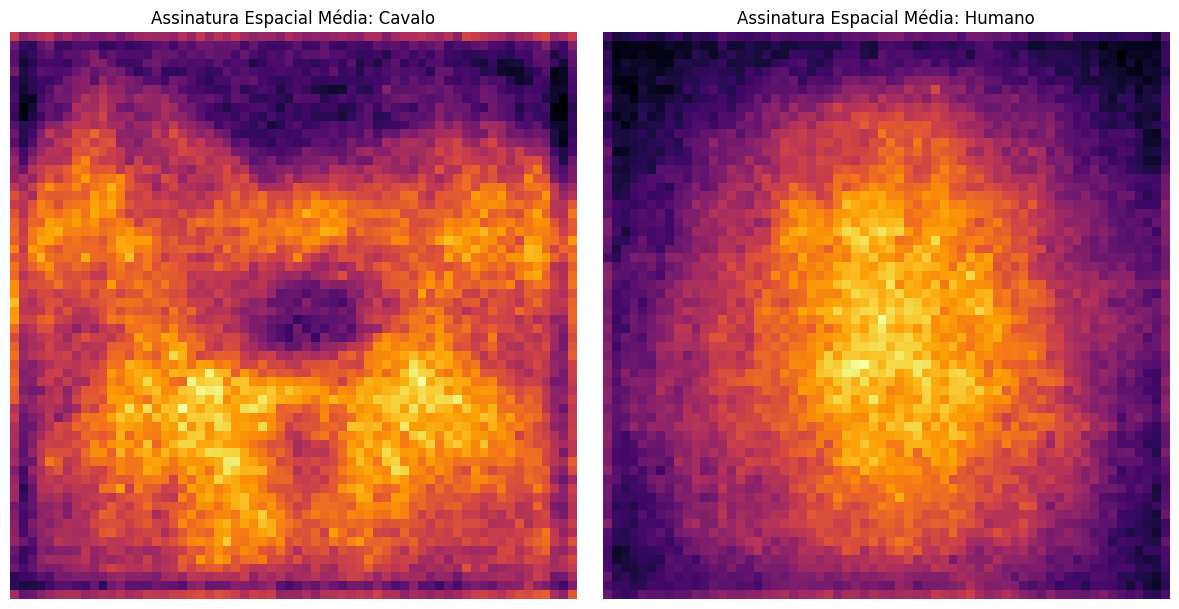

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Caminho da pasta de destino
pasta_versoes = '/content/drive/MyDrive/Beckup_IC/Trabalho_SistemasInteligentes/versoes'

# Calcula as médias
assinatura_media_cavalo = np.mean(resultadoVetores_caracteristica4_cavalos_np, axis=0).reshape(64, 64)
assinatura_media_humano = np.mean(resultadoVetores_caracteristica4_nao_cavalos_np, axis=0).reshape(64, 64)

# Plotagem lado a lado
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(assinatura_media_cavalo, cmap='inferno')
ax[0].set_title("Assinatura Espacial Média: Cavalo")
ax[0].axis('off')

ax[1].imshow(assinatura_media_humano, cmap='inferno')
ax[1].set_title("Assinatura Espacial Média: Humano")
ax[1].axis('off')

plt.tight_layout()

# Salva a imagem dentro da pasta 'versoes'
plt.savefig(os.path.join(pasta_versoes, 'assinaturas_espaciais.png'))

plt.show()

# Treino e Comparativo de Modelos

Nesta etapa, realizei o treinamento e a avaliação comparativa de dois algoritmos distintos para a classificação equina: o **$k$-NN** e o **Random Forest**.

#### 1. k-Nearest Neighbors ($k$-NN)
Diferente de modelos paramétricos, o $k$-NN opera baseado em instâncias:
* **Fase de Treino (Memorização):** Ao executar o `.fit()`, o algoritmo apenas indexa os vetores de 28.672 características em uma estrutura de busca. Não ocorrem ciclos de otimização (*épocas*), pois o modelo não aprende parâmetros internos.
* **Fase de Teste (Consulta):** A "inteligência" ocorre durante o `.predict()`, onde o modelo busca a similaridade geométrica entre os pontos no espaço de características.

#### 2. Random Forest
Devido à natureza complexa dos dados e à sobreposição observada na análise exploratória, o $k$-NN apresentou métricas limitadas para a **Classe 1 (Equina)**, nossa principal classe de interesse.

Para mitigar essa limitação, apliquei o **Random Forest**:
* **Motivação:** Diferente do $k$-NN, que é sensível a ruídos locais e distâncias fixas, o Random Forest utiliza um *ensemble* de árvores de decisão. Isso permite o aprendizado de fronteiras não-lineares complexas, aumentando significativamente a robustez e a capacidade de generalização do sistema.
* **Objetivo:** Superar a sensibilidade do $k$-NN e maximizar a taxa de detecção (Recall) de instâncias equinas, garantindo maior precisão clínica para o filtro de pré-processamento.

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Definição do Modelo
# 'n_neighbors=x' parâmetro define a quantidade de "vizinhos" que o algoritmo consultará para tomar uma decisão.
knn = KNeighborsClassifier(n_neighbors=9, metric='manhattan')

# Treino (O 'fit' mapeia os dados no espaço vetorial)
knn.fit(X_train, y_train)

# Predição
# O modelo calcula a distância dos novos pontos (X_test) aos vizinhos mais próximos
y_probs = knn.predict_proba(X_test)

# Agora o y_probs existe, e podemos aplicar o limiar
limiar = 0.2
y_pred_ajustado = (y_probs[:, 1] >= limiar).astype(int)

# Avaliação
print("Acurácia com limiar 0.2:", accuracy_score(y_test, y_pred_ajustado))
print(classification_report(y_test, y_pred_ajustado))

Acurácia com limiar 0.2: 0.7947761194029851
              precision    recall  f1-score   support

         0.0       0.87      0.69      0.77       134
         1.0       0.75      0.90      0.81       134

    accuracy                           0.79       268
   macro avg       0.81      0.79      0.79       268
weighted avg       0.81      0.79      0.79       268



Canto superior esquerdo (VN): 93 fotos (69.40%)
Canto superior direito (FP): 41 fotos (30.60%)
Canto inferior esquerdo (FN): 14 fotos (10.45%)
Canto inferior direito (VP): 120 fotos (89.55%)


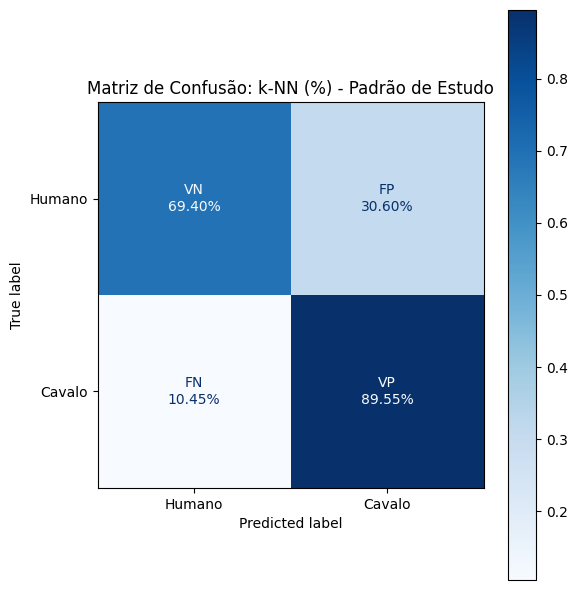

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Matriz bruta (contagem de fotos)
cm_bruta = confusion_matrix(y_test.astype(int), y_pred_ajustado.astype(int))

# Calcula os totais de cada linha para saber o divisor
total_humano = cm_bruta[0, 0] + cm_bruta[0, 1]
total_cavalo = cm_bruta[1, 0] + cm_bruta[1, 1]

# Porcentagem por posição
print(f"Canto superior esquerdo (VN): {cm_bruta[0,0]} fotos ({ (cm_bruta[0,0]/total_humano)*100 :.2f}%)")
print(f"Canto superior direito (FP): {cm_bruta[0,1]} fotos ({ (cm_bruta[0,1]/total_humano)*100 :.2f}%)")
print(f"Canto inferior esquerdo (FN): {cm_bruta[1,0]} fotos ({ (cm_bruta[1,0]/total_cavalo)*100 :.2f}%)")
print(f"Canto inferior direito (VP): {cm_bruta[1,1]} fotos ({ (cm_bruta[1,1]/total_cavalo)*100 :.2f}%)")

# MATRIZ DE CONFUSÃO: k-NN (Porcentagem)
# matriz está baseada especificamente no Recall (ou Sensibilidade/Taxa de Verdadeiros Positivos)
# normalize='true' para obter as taxas (Recall)
cm_knn_percent = confusion_matrix(y_test.astype(int), y_pred_ajustado.astype(int), normalize='true')

# organização padrão da biblioteca que você usa (Scikit-Learn)
# [0,0] = Cavalo/Cavalo (VN)
# [0,1] = Cavalo/Humano (FP)
# [1,0] = Humano/Cavalo (FN)
# [1,1] = Humano/Humano (VP)
labels = [['VN', 'FP'],
          ['FN', 'VP']]

fig, ax = plt.subplots(figsize=(6, 6))

# onfusionMatrixDisplay para manter o padrão visual do Random Forest
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn_percent, display_labels=['Humano', 'Cavalo'])
# O parâmetro values_format='.2%' converte os decimais (ex: 0.85) para porcentagem (ex: 85.00%)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='.2%')

# Loop para aplicar os nomes técnicos nos locais corretos conforme sua aula
for i in range(2):
    for j in range(2):
        current_text = disp.text_[i, j].get_text()
        disp.text_[i, j].set_text(f"{labels[i][j]}\n{current_text}")

plt.title("Matriz de Confusão: k-NN (%) - Padrão de Estudo")
plt.tight_layout()
plt.show()

In [44]:
# RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
# VERSAO 8
# Inicialização do modelo Random Forest
# n_estimators=100: cria 100 árvores de decisão para votação (mais robusto que 1 árvore)
# random_state=42: garante que o resultado seja reprodutível em cada execução
# rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# VERSAO 9
rf_model = RandomForestClassifier(
    n_estimators=200,      # Aumenta a diversidade das árvores
    max_depth=10,          # Limita a profundidade para evitar overfitting
    min_samples_split=5,   # Força o modelo a ser mais robusto
    random_state=42
)

# Treinamento com os mesmos dados do KNN
rf_model.fit(X_train, y_train)

# Predição
y_pred_rf = rf_model.predict(X_test)

# Avaliação
print("Relatório de Classificação - Random Forest:")
print(classification_report(y_test, y_pred_rf))

Relatório de Classificação - Random Forest:
              precision    recall  f1-score   support

         0.0       0.85      0.83      0.84       134
         1.0       0.83      0.86      0.85       134

    accuracy                           0.84       268
   macro avg       0.84      0.84      0.84       268
weighted avg       0.84      0.84      0.84       268



Canto superior esquerdo (VN): 111 fotos (82.84%)
Canto superior direito (FP): 23 fotos (17.16%)
Canto inferior esquerdo (FN): 19 fotos (14.18%)
Canto inferior direito (VP): 115 fotos (85.82%)


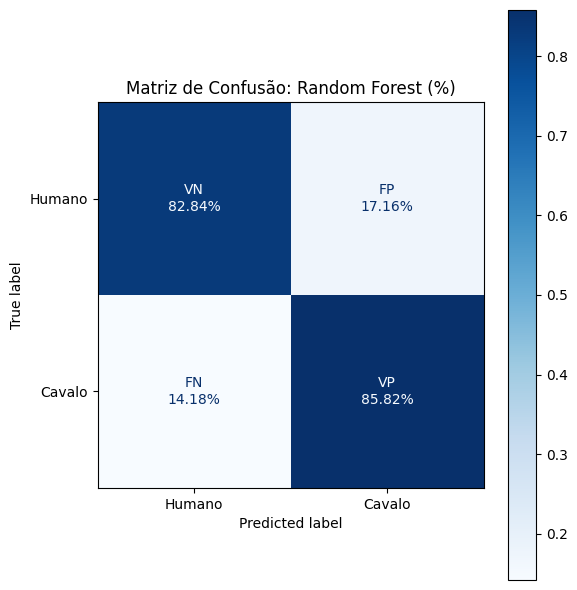

In [45]:
# MATRIZ DE CONFUSÃO Random Florest
# Matriz bruta (contagem de fotos)
cm_bruta = confusion_matrix(y_test.astype(int), y_pred_rf.astype(int))

# Calcula os totais de cada linha para saber o divisor
total_humano = cm_bruta[0, 0] + cm_bruta[0, 1]
total_cavalo = cm_bruta[1, 0] + cm_bruta[1, 1]

# Porcentagem por posição para conferência rápida
print(f"Canto superior esquerdo (VN): {cm_bruta[0,0]} fotos ({ (cm_bruta[0,0]/total_humano)*100 :.2f}%)")
print(f"Canto superior direito (FP): {cm_bruta[0,1]} fotos ({ (cm_bruta[0,1]/total_humano)*100 :.2f}%)")
print(f"Canto inferior esquerdo (FN): {cm_bruta[1,0]} fotos ({ (cm_bruta[1,0]/total_cavalo)*100 :.2f}%)")
print(f"Canto inferior direito (VP): {cm_bruta[1,1]} fotos ({ (cm_bruta[1,1]/total_cavalo)*100 :.2f}%)")

# normalize='true' calcula a porcentagem por linha (recall de cada classe)
cm_percent = confusion_matrix(y_test, y_pred_rf, normalize='true')
labels = [['VN', 'FP'],
          ['FN', 'VP']]

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=['Humano', 'Cavalo'])

# fmt='.2%' formata os números como porcentagem com 2 casas decimais
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='.2%')
# Loop para aplicar os nomes técnicos nos locais corretos conforme sua aula
for i in range(2):
    for j in range(2):
        current_text = disp.text_[i, j].get_text()
        disp.text_[i, j].set_text(f"{labels[i][j]}\n{current_text}")

plt.title("Matriz de Confusão: Random Forest (%)")
plt.tight_layout()
plt.show()

# Salvando resultados Drive

In [40]:
import pandas as pd
import os
from sklearn.metrics import classification_report, accuracy_score

# Definições SALVAMENTO KNN
nome_da_versao = 'v7'
limiar_utilizado = 0.4
base_path = '/content/drive/MyDrive/Beckup_IC/Trabalho_SistemasInteligentes/versoes'
caminho_csv = os.path.join(base_path, 'historico_metricas.csv')

# Matriz de Confusão
caminho_versao = os.path.join(base_path, nome_da_versao)
os.makedirs(caminho_versao, exist_ok=True)
fig.savefig(os.path.join(caminho_versao, 'matriz_confusao_knn.png'))

# Geração do Relatório
report = classification_report(y_test.astype(int), y_pred_ajustado.astype(int), output_dict=True)

# Mapeamento das métricas
nova_linha = {
    'versao': nome_da_versao,
    'limiar': limiar_utilizado,
    'accuracy': report['accuracy'],
    'precision_0': report['0']['precision'],
    'recall_0': report['0']['recall'],
    'f1_0': report['0']['f1-score'],
    'precision_1': report['1']['precision'],
    'recall_1': report['1']['recall'],
    'f1_1': report['1']['f1-score'],
    'f1_macro': report['macro avg']['f1-score']
}

# Salva no CSV
df_nova_linha = pd.DataFrame([nova_linha])
if not os.path.isfile(caminho_csv):
    df_nova_linha.to_csv(caminho_csv, index=False)
else:
    df_nova_linha.to_csv(caminho_csv, mode='a', header=False, index=False)

print(f"Métricas da versão {nome_da_versao} (limiar {limiar_utilizado}) registradas.")

Métricas da versão v7 (limiar 0.4) registradas.


In [46]:
import pandas as pd
import os
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# DEFINIÇÕES SALVA RANDOM FOREST
nome_da_versao = 'v9' # Defina o nome (ex: v7, v8...)
limiar_utilizado = 'N/A' # Random Forest usa classe direta, não probabilística padrão
base_path = '/content/drive/MyDrive/Beckup_IC/Trabalho_SistemasInteligentes/versoes'
caminho_csv = os.path.join(base_path, 'historico_metricas.csv')

# SALVAMENTO DA MATRIZ
# Cria a pasta da versão se não existir
caminho_versao = os.path.join(base_path, nome_da_versao)
os.makedirs(caminho_versao, exist_ok=True)

# Salva a matriz (assume que o objeto 'fig' já está criado pela sua plotagem anterior)
caminho_salvamento = os.path.join(caminho_versao, 'matriz_confusao_rf.png')
fig.savefig(caminho_salvamento)

# GERAÇÃO E SALVAMENTO DE MÉTRICAS
# Calcula o report para o Random Forest
report_rf = classification_report(y_test.astype(int), y_pred_rf.astype(int), output_dict=True)

nova_linha = {
    'versao': f"{nome_da_versao}_RF",
    'limiar': limiar_utilizado,
    'accuracy': report_rf['accuracy'],
    'precision_0': report_rf['0']['precision'],
    'recall_0': report_rf['0']['recall'],
    'f1_0': report_rf['0']['f1-score'],
    'precision_1': report_rf['1']['precision'],
    'recall_1': report_rf['1']['recall'],
    'f1_1': report_rf['1']['f1-score'],
    'f1_macro': report_rf['macro avg']['f1-score']
}

# ADICIONA AO CSV
df_nova_linha = pd.DataFrame([nova_linha])
if not os.path.isfile(caminho_csv):
    df_nova_linha.to_csv(caminho_csv, index=False)
else:
    df_nova_linha.to_csv(caminho_csv, mode='a', header=False, index=False)

print(f"Métricas do Random Forest ({nome_da_versao}) registradas em: {caminho_csv}")
print(f"Matriz de confusão salva em: {caminho_salvamento}")

Métricas do Random Forest (v9) registradas em: /content/drive/MyDrive/Beckup_IC/Trabalho_SistemasInteligentes/versoes/historico_metricas.csv
Matriz de confusão salva em: /content/drive/MyDrive/Beckup_IC/Trabalho_SistemasInteligentes/versoes/v9/matriz_confusao_rf.png


In [47]:
# Carrega a tabela
df_final = pd.read_csv('/content/drive/MyDrive/Beckup_IC/Trabalho_SistemasInteligentes/versoes/historico_metricas.csv')

# Exibe a tabela organizada
display(df_final)

,versao,limiar,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,f1_macro
0,v1,0.4,0.716418,0.659341,0.895522,0.759494,0.837209,0.537313,0.654545,0.707020
1,v2,0.4,0.783582,0.737500,0.880597,0.802721,0.851852,0.686567,0.760331,0.781526
2,v3,0.4,0.768657,0.714286,0.895522,0.794702,0.860000,0.641791,0.735043,0.764872
3,v4,0.4,0.705224,0.639594,0.940299,0.761329,0.887324,0.470149,0.614634,0.687982
4,v5,0.4,0.783582,0.737500,0.880597,0.802721,0.851852,0.686567,0.760331,0.781526
5,v6,0.4,0.820896,0.807143,0.843284,0.824818,0.835938,0.798507,0.816794,0.820806
6,v7,0.4,0.794776,0.869159,0.694030,0.771784,0.745342,0.895522,0.813559,0.792672
7,v8_RF,NaN,0.854478,0.846715,0.865672,0.856089,0.862595,0.843284,0.852830,0.854459
8,v9_RF,NaN,0.843284,0.853846,0.828358,0.840909,0.833333,0.858209,0.845588,0.843249
